## AFFICIONADO COFFEE ROASTERS

In [219]:
# Import libraries 
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore') 

### SECTION 1 : DATA INGESTION & VALIDATION 

In [220]:
# Goal: Load the data and make sure it is clean and correct 
# before we do any analysis, Dirty data = wrong results! 

df = pd.read_csv(r"C:\Users\SANDEEP\Downloads\Afficionado Coffee Roasters.xlsx - Transactions.csv") 

In [221]:
print("\n First 5 rows of raw data") 
print(df.head(5))


 First 5 rows of raw data
   transaction_id  year transaction_time  transaction_qty  store_id  \
0               1  2025          7:06:11                2         5   
1               2  2025          7:08:56                2         5   
2               3  2025          7:14:04                2         5   
3               4  2025          7:20:24                1         5   
4               5  2025          7:22:41                2         5   

    store_location  product_id  unit_price    product_category  \
0  Lower Manhattan          32         3.0              Coffee   
1  Lower Manhattan          57         3.1                 Tea   
2  Lower Manhattan          59         4.5  Drinking Chocolate   
3  Lower Manhattan          22         2.0              Coffee   
4  Lower Manhattan          57         3.1                 Tea   

            product_type               product_detail  
0  Gourmet brewed coffee                  Ethiopia Rg  
1        Brewed Chai tea     Spicy Ey

In [222]:
print(f" Total rows     : {len(df):,}")           # How many transactions 
print(f" Total column   : {len(df.columns)}")     # How many columns 
print(f" column names   : {list(df.columns)}")    # Print all column names

 Total rows     : 149,116
 Total column   : 11
 column names   : ['transaction_id', 'year', 'transaction_time', 'transaction_qty', 'store_id', 'store_location', 'product_id', 'unit_price', 'product_category', 'product_type', 'product_detail']


In [223]:
df.dtypes

transaction_id        int64
year                  int64
transaction_time     object
transaction_qty       int64
store_id              int64
store_location       object
product_id            int64
unit_price          float64
product_category     object
product_type         object
product_detail       object
dtype: object

In [224]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   year              149116 non-null  int64  
 2   transaction_time  149116 non-null  object 
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  object 
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  object 
 9   product_type      149116 non-null  object 
 10  product_detail    149116 non-null  object 
dtypes: float64(1), int64(5), object(5)
memory usage: 12.5+ MB


In [225]:
df.describe()

,transaction_id,year,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116.0,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2025.0,1.438276,5.342063,47.918607,3.382219
std,43153.600016,0.0,0.542509,2.074241,17.930020,2.658723
min,1.000000,2025.0,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2025.0,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2025.0,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2025.0,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2025.0,8.000000,8.000000,87.000000,45.000000


In [226]:
df.describe(include= "all")

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
count,149116.000000,149116.0,149116,149116.000000,149116.000000,149116,149116.000000,149116.000000,149116,149116,149116
unique,NaN,NaN,25762,NaN,NaN,3,NaN,NaN,9,29,80
top,NaN,NaN,9:31:15,NaN,NaN,Hell's Kitchen,NaN,NaN,Coffee,Brewed Chai tea,Chocolate Croissant
freq,NaN,NaN,41,NaN,NaN,50735,NaN,NaN,58416,17183,3076
mean,74737.371872,2025.0,NaN,1.438276,5.342063,NaN,47.918607,3.382219,NaN,NaN,NaN
std,43153.600016,0.0,NaN,0.542509,2.074241,NaN,17.930020,2.658723,NaN,NaN,NaN
min,1.000000,2025.0,NaN,1.000000,3.000000,NaN,1.000000,0.800000,NaN,NaN,NaN
25%,37335.750000,2025.0,NaN,1.000000,3.000000,NaN,33.000000,2.500000,NaN,NaN,NaN
50%,74727.500000,2025.0,NaN,1.000000,5.000000,NaN,47.000000,3.000000,NaN,NaN,NaN
75%,112094.250000,2025.0,NaN,2.000000,8.000000,NaN,60.000000,3.750000,NaN,NaN,NaN


In [227]:
print("\n Validating timestamp formats") 
df["transaction_time"] = pd.to_datetime(
    df["transaction_time"], 
    format="%H:%M:%S", 
    errors= "coerce"
)


 Validating timestamp formats


In [228]:
# checking transaction time datatype 
df.dtypes

transaction_id               int64
year                         int64
transaction_time    datetime64[ns]
transaction_qty              int64
store_id                     int64
store_location              object
product_id                   int64
unit_price                 float64
product_category            object
product_type                object
product_detail              object
dtype: object

In [229]:
# checking missing values 
df.isnull().sum()

transaction_id      0
year                0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

In [230]:
# checking duplicate values 
df.duplicated().sum()

np.int64(0)

### verify logical consistency 

### Business rules : 
* transaction_qty must be greater than 0 (can't sell 0 coffees)
* unit_price must be greater than 0 (can't have a free or negative price)
* Any row that breaks these rules is invalid and must be removed.

In [231]:
# Find rows where quantity is 0 or negative 
invalid_qty = df[df['transaction_qty']<= 0 ]
print(f"   Rows where qty ≤ 0   : {len(invalid_qty)}")

   Rows where qty ≤ 0   : 0


In [232]:
 # Find rows where price is 0 or negative
invalid_price = df[df['unit_price'] <= 0]
print(f"   Rows where price ≤ 0 : {len(invalid_price)}")

   Rows where price ≤ 0 : 0


In [233]:
len(df)

149116

## PHASE 2 — FEATURE ENGINEERING

In [234]:
# Step 2.1 — Create a REVENUE column (the most important one!)
# Revenue = how much money each transaction made
df["revenue"] = df["transaction_qty"] * df["unit_price"]
print("✅ Revenue column added!")
print(df[["transaction_qty", "unit_price", "revenue"]].head(5))

✅ Revenue column added!
   transaction_qty  unit_price  revenue
0                2         3.0      6.0
1                2         3.1      6.2
2                2         4.5      9.0
3                1         2.0      2.0
4                2         3.1      6.2


In [235]:
# Step 2.2 — Extract HOUR from transaction_time
# This tells us what hour of day each sale happened (0–23)
df["hour"] = df["transaction_time"].dt.hour
print("\n✅ Hour column added!")
print(df["hour"].value_counts().sort_index().head(5))


✅ Hour column added!
hour
6      4594
7     13428
8     17654
9     17764
10    18545
Name: count, dtype: int64


In [236]:
# Step 2.3 — Extract MINUTE (optional, for detailed time analysis)
df["minute"] = df["transaction_time"].dt.minute

In [237]:
# Step 2.4 — Label PEAK vs OFF-PEAK hours
# Morning rush = 7–10am, Lunch = 12–2pm, everything else = off-peak
def label_time_period(hour):
    if 7 <= hour <= 10:
        return "Morning Rush"
    elif 12 <= hour <= 14:
        return "Lunch Rush"
    elif 15 <= hour <= 18:
        return "Afternoon"
    else:
        return "Off Peak"

In [238]:
df["time_period"] = df["hour"].apply(label_time_period)
print("\n✅ Time period labels added!")
print(df["time_period"].value_counts())


✅ Time period labels added!
time_period
Morning Rush    67391
Afternoon       34315
Lunch Rush      26355
Off Peak        21055
Name: count, dtype: int64


In [239]:
# Step 2.5 — Quick check: what does our enhanced dataframe look like?
print("\n📋 New columns added:")
print(df[["transaction_id", "revenue", "hour", "time_period"]].head(5))


📋 New columns added:
   transaction_id  revenue  hour   time_period
0               1      6.0     7  Morning Rush
1               2      6.2     7  Morning Rush
2               3      9.0     7  Morning Rush
3               4      2.0     7  Morning Rush
4               5      6.2     7  Morning Rush


##  PHASE 3 — STORE & LOCATION ANALYSIS

In [240]:
# Which store makes the most money?

In [241]:
import matplotlib.pyplot as plt   # for charts
import matplotlib.ticker as mtick  # for formatting numbers on charts

In [242]:
# Step 3.1 — Total revenue per store location
store_revenue = df.groupby("store_location")["revenue"].sum().sort_values(ascending=False)
print("\n💰 Revenue by Store Location:")
for store, rev in store_revenue.items():
    print(f"   {store:<20} : ${rev:>12,.2f}")


💰 Revenue by Store Location:
   Hell's Kitchen       : $  236,511.17
   Astoria              : $  232,243.91
   Lower Manhattan      : $  230,057.25


In [243]:
# Step 3.2 — Number of transactions per store
store_txns = df.groupby("store_location")["transaction_id"].count().sort_values(ascending=False)
print("\n🧾 Transactions by Store Location:")
for store, txns in store_txns.items():
    print(f"   {store:<20} : {txns:>10,} transactions")


🧾 Transactions by Store Location:
   Hell's Kitchen       :     50,735 transactions
   Astoria              :     50,599 transactions
   Lower Manhattan      :     47,782 transactions


In [244]:
# Step 3.3 — Average revenue per transaction per store
store_avg = df.groupby("store_location")["revenue"].mean().sort_values(ascending=False)
print("\n📊 Avg Revenue per Transaction:")
for store, avg in store_avg.items():
    print(f"   {store:<20} : ${avg:>8.2f}")


📊 Avg Revenue per Transaction:
   Lower Manhattan      : $    4.81
   Hell's Kitchen       : $    4.66
   Astoria              : $    4.59


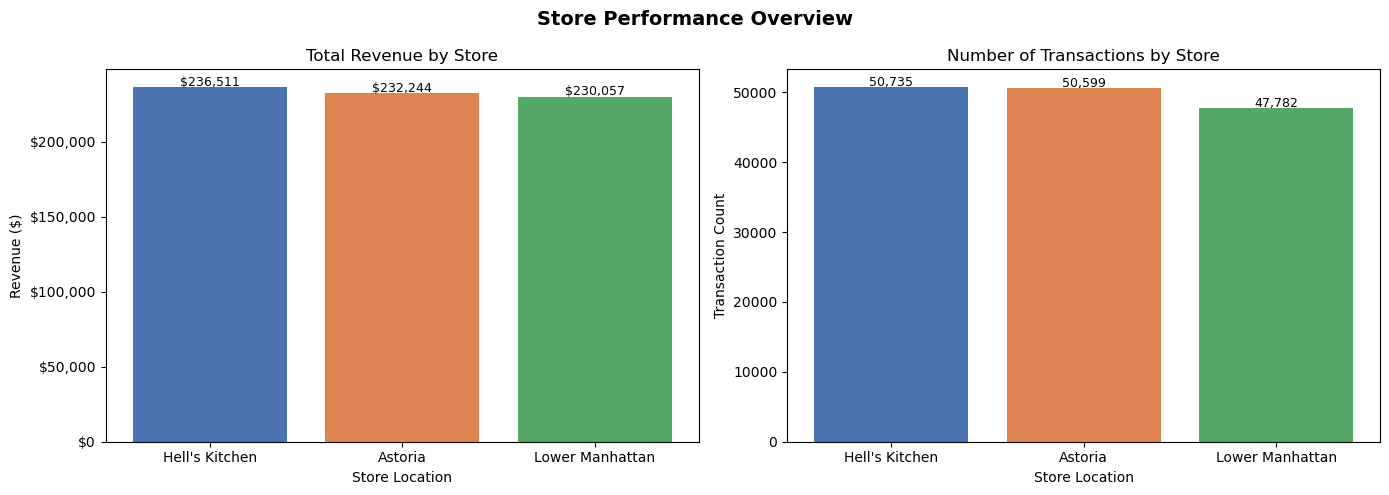

In [245]:
# Step 3.4 — Bar chart: Total revenue by store
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Store Performance Overview", fontsize=14, fontweight="bold") # Left chart — Total revenue

axes[0].bar(store_revenue.index, store_revenue.values, color=["#4C72B0","#DD8452","#55A868"])
axes[0].set_title("Total Revenue by Store")
axes[0].set_xlabel("Store Location")
axes[0].set_ylabel("Revenue ($)")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for i, v in enumerate(store_revenue.values):
    axes[0].text(i, v + 1000, f"${v:,.0f}", ha="center", fontsize=9)

# Right chart — Number of transactions
axes[1].bar(store_txns.index, store_txns.values, color=["#4C72B0","#DD8452","#55A868"])
axes[1].set_title("Number of Transactions by Store")
axes[1].set_xlabel("Store Location")
axes[1].set_ylabel("Transaction Count")
for i, v in enumerate(store_txns.values):
    axes[1].text(i, v + 100, f"{v:,}", ha="center", fontsize=9)


plt.tight_layout()
plt.savefig("store_performance.png", dpi=150, bbox_inches="tight")
plt.show()

## PHASE 4 — PRODUCT & CATEGORY ANALYSIS

In [246]:
# What sells the most? What makes the most money?

In [247]:
# Step 4.1 — Revenue by Product CATEGORY (Coffee, Tea, etc.)
category_revenue = df.groupby("product_category")["revenue"].sum().sort_values(ascending=False)
print("\n☕ Revenue by Product Category:")
total_rev = category_revenue.sum()
for cat, rev in category_revenue.items():
    pct = (rev / total_rev) * 100
    print(f"   {cat:<25} : ${rev:>12,.2f}  ({pct:.1f}%)")


☕ Revenue by Product Category:
   Coffee                    : $  269,952.45  (38.6%)
   Tea                       : $  196,405.95  (28.1%)
   Bakery                    : $   82,315.64  (11.8%)
   Drinking Chocolate        : $   72,416.00  (10.4%)
   Coffee beans              : $   40,085.25  (5.7%)
   Branded                   : $   13,607.00  (1.9%)
   Loose Tea                 : $   11,213.60  (1.6%)
   Flavours                  : $    8,408.80  (1.2%)
   Packaged Chocolate        : $    4,407.64  (0.6%)


In [248]:
# Step 4.2 — Revenue by Product TYPE (more detailed than category)
type_revenue = df.groupby("product_type")["revenue"].sum().sort_values(ascending=False)
print("\n🏷️  Top 10 Product Types by Revenue:")
for ptype, rev in type_revenue.head(10).items():
    print(f"   {ptype:<30} : ${rev:>10,.2f}")


🏷️  Top 10 Product Types by Revenue:
   Barista Espresso               : $ 91,406.20
   Brewed Chai tea                : $ 77,081.95
   Hot chocolate                  : $ 72,416.00
   Gourmet brewed coffee          : $ 70,034.60
   Brewed Black tea               : $ 47,932.00
   Brewed herbal tea              : $ 47,539.50
   Premium brewed coffee          : $ 38,781.15
   Organic brewed coffee          : $ 37,746.50
   Scone                          : $ 36,866.12
   Drip coffee                    : $ 31,984.00


In [249]:
# Step 4.3 — Top 10 individual products (product_detail)
detail_revenue = df.groupby("product_detail")["revenue"].sum().sort_values(ascending=False)
print("\n🥇 Top 10 Products (Detailed) by Revenue:")
for i, (product, rev) in enumerate(detail_revenue.head(10).items(), 1):
    print(f"   {i:>2}. {product:<35} : ${rev:>10,.2f}")


🥇 Top 10 Products (Detailed) by Revenue:
    1. Sustainably Grown Organic Lg        : $ 21,151.75
    2. Dark chocolate Lg                   : $ 21,006.00
    3. Latte Rg                            : $ 19,112.25
    4. Cappuccino Lg                       : $ 17,641.75
    5. Morning Sunrise Chai Lg             : $ 17,384.00
    6. Latte                               : $ 17,257.50
    7. Jamaican Coffee River Lg            : $ 16,481.25
    8. Sustainably Grown Organic Rg        : $ 16,233.75
    9. Cappuccino                          : $ 15,997.50
   10. Brazilian Lg                        : $ 15,109.50


In [250]:
# Step 4.4 — Quantity sold per category
category_qty = df.groupby("product_category")["transaction_qty"].sum().sort_values(ascending=False)
print("\n📦 Units Sold by Category:")
for cat, qty in category_qty.items():
    print(f"   {cat:<25} : {qty:>10,} units")


📦 Units Sold by Category:
   Coffee                    :     89,250 units
   Tea                       :     69,737 units
   Bakery                    :     23,214 units
   Drinking Chocolate        :     17,457 units
   Flavours                  :     10,511 units
   Coffee beans              :      1,828 units
   Loose Tea                 :      1,210 units
   Branded                   :        776 units
   Packaged Chocolate        :        487 units


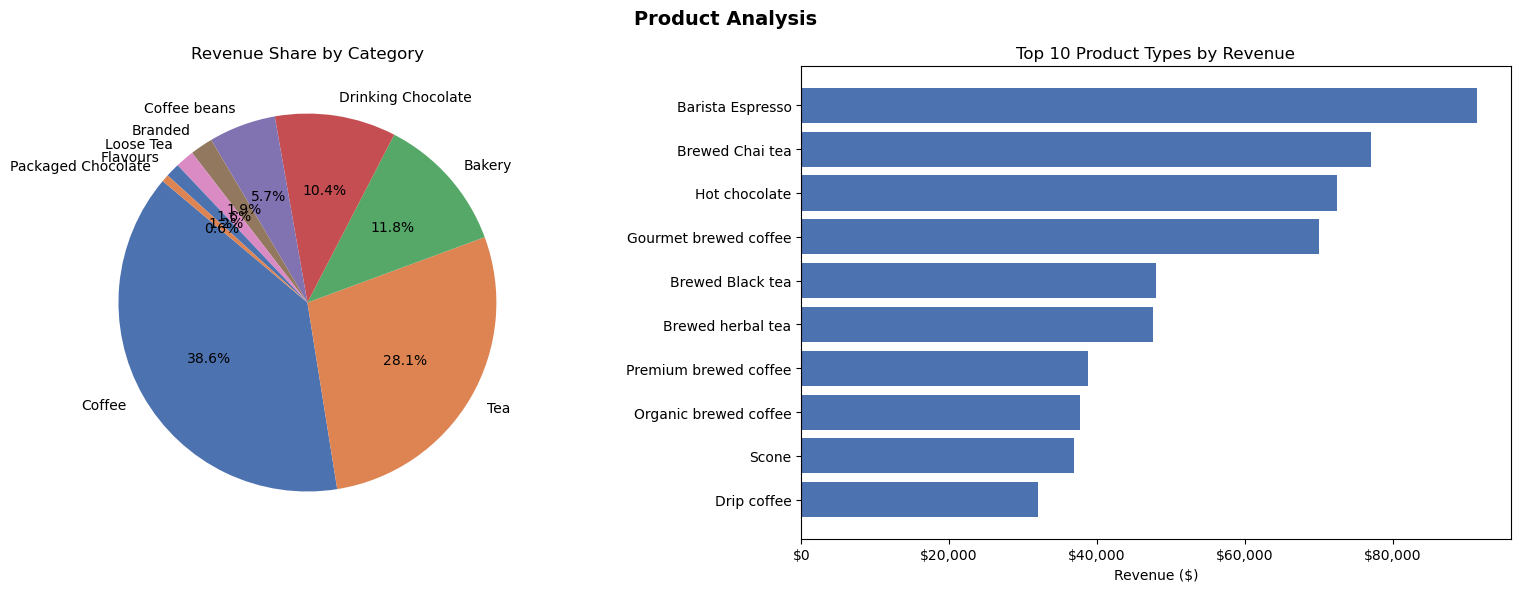

✅ Chart saved as product_analysis.png


In [251]:
# Step 4.5 — Charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Product Analysis", fontsize=14, fontweight="bold")

# Left — Pie chart for category revenue share
axes[0].pie(
    category_revenue.values,
    labels=category_revenue.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2","#937860","#DA8BC3"]
)
axes[0].set_title("Revenue Share by Category")

# Right — Horizontal bar for top 10 product types
colors_bar = ["#4C72B0"] * 10
axes[1].barh(type_revenue.head(10).index[::-1], type_revenue.head(10).values[::-1], color=colors_bar)
axes[1].set_title("Top 10 Product Types by Revenue")
axes[1].set_xlabel("Revenue ($)")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("product_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved as product_analysis.png")

## PHASE 5 — TIME-BASED TRENDS

In [252]:
# When is the busiest time? What hours drive the most sales?

In [253]:
# Step 5.1 — Revenue by HOUR of day
hourly_revenue = df.groupby("hour")["revenue"].sum().sort_index()
print("\n🕐 Revenue by Hour of Day:")
for h, rev in hourly_revenue.items():
    bar = "█" * int(rev / hourly_revenue.max() * 20)  # mini bar in console
    print(f"   {h:>2}:00  {bar:<20}  ${rev:>10,.2f}")


🕐 Revenue by Hour of Day:
    6:00  ████                  $ 21,900.27
    7:00  ██████████████        $ 63,526.47
    8:00  ██████████████████    $ 82,699.87
    9:00  ███████████████████   $ 85,169.53
   10:00  ████████████████████  $ 88,673.39
   11:00  ██████████            $ 46,319.14
   12:00  █████████             $ 40,192.79
   13:00  █████████             $ 40,367.45
   14:00  █████████             $ 41,304.74
   15:00  █████████             $ 41,733.10
   16:00  █████████             $ 41,122.75
   17:00  █████████             $ 40,134.31
   18:00  ███████               $ 34,286.20
   19:00  ██████                $ 28,446.68
   20:00                        $  2,935.64


In [254]:
# Step 5.2 — Transactions by hour (how many sales happen each hour?)
hourly_txns = df.groupby("hour")["transaction_id"].count().sort_index()
print("\n🔢 Transaction Count by Hour:")
for h, txns in hourly_txns.items():
    bar = "█" * int(txns / hourly_txns.max() * 20)
    print(f"   {h:>2}:00  {bar:<20}  {txns:>8,} transactions")


🔢 Transaction Count by Hour:
    6:00  ████                     4,594 transactions
    7:00  ██████████████          13,428 transactions
    8:00  ███████████████████     17,654 transactions
    9:00  ███████████████████     17,764 transactions
   10:00  ████████████████████    18,545 transactions
   11:00  ██████████               9,766 transactions
   12:00  █████████                8,708 transactions
   13:00  █████████                8,714 transactions
   14:00  █████████                8,933 transactions
   15:00  █████████                8,979 transactions
   16:00  █████████                9,093 transactions
   17:00  █████████                8,745 transactions
   18:00  ████████                 7,498 transactions
   19:00  ██████                   6,092 transactions
   20:00                             603 transactions


In [255]:
# Step 5.3 — Revenue by time period (Morning Rush, Lunch, etc.)
period_revenue = df.groupby("time_period")["revenue"].sum().sort_values(ascending=False)
print("\n⏰ Revenue by Time Period:")
for period, rev in period_revenue.items():
    pct = (rev / period_revenue.sum()) * 100
    print(f"   {period:<15} : ${rev:>12,.2f}  ({pct:.1f}%)")


⏰ Revenue by Time Period:
   Morning Rush    : $  320,069.26  (45.8%)
   Afternoon       : $  157,276.36  (22.5%)
   Lunch Rush      : $  121,864.98  (17.4%)
   Off Peak        : $   99,601.73  (14.3%)


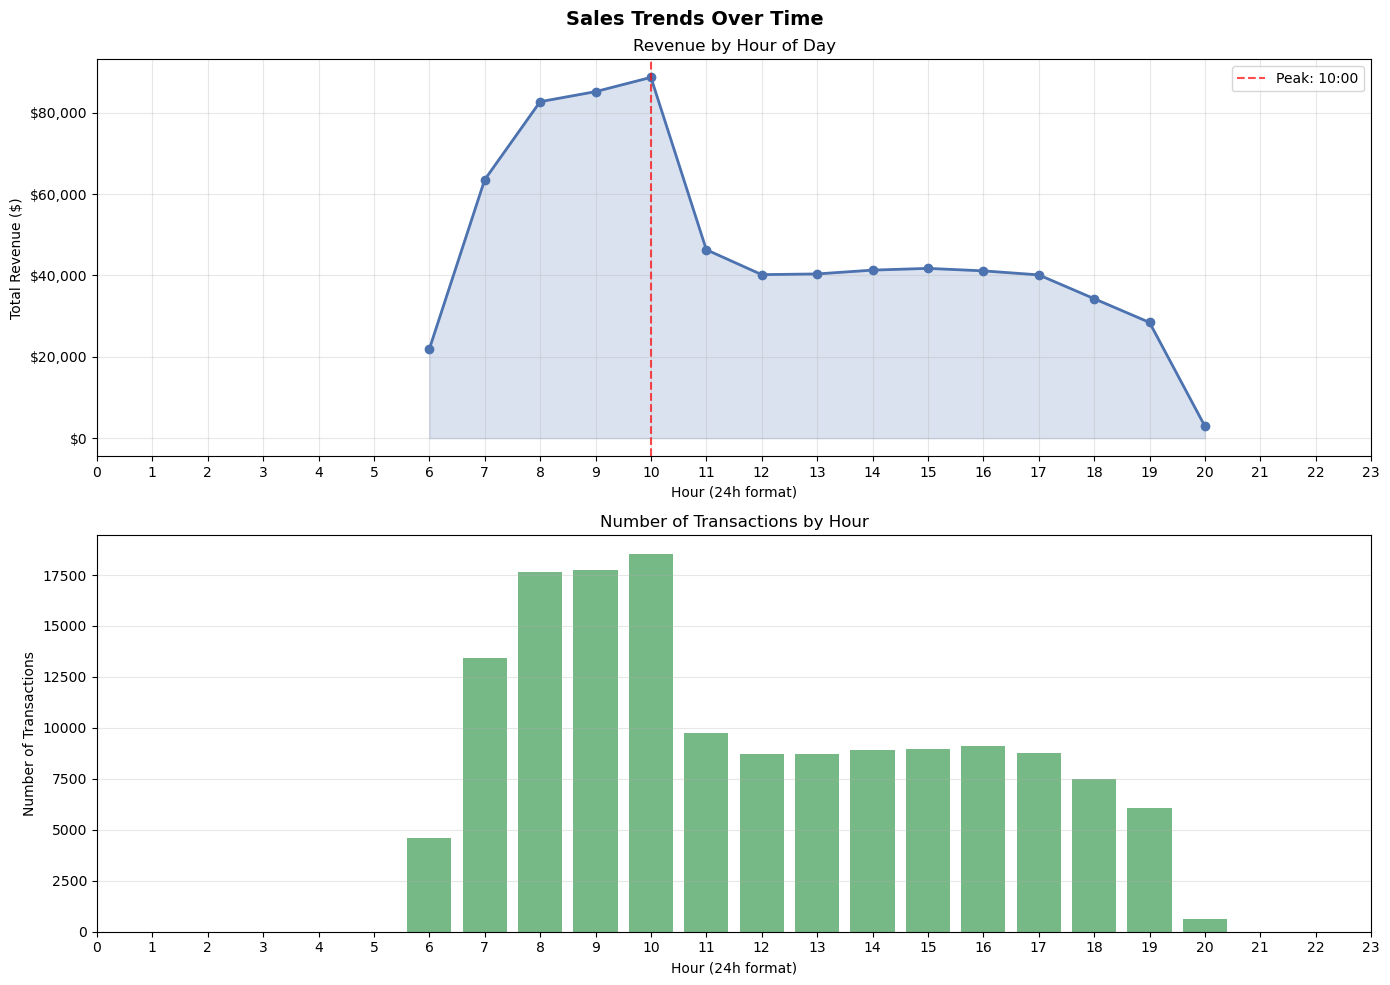

✅ Chart saved as time_trends.png


In [256]:
# Step 5.4 — Charts for time analysis
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("Sales Trends Over Time", fontsize=14, fontweight="bold")

# Top chart — Revenue by hour (line chart)
axes[0].plot(hourly_revenue.index, hourly_revenue.values, marker="o", color="#4C72B0", linewidth=2)
axes[0].fill_between(hourly_revenue.index, hourly_revenue.values, alpha=0.2, color="#4C72B0")
axes[0].set_title("Revenue by Hour of Day")
axes[0].set_xlabel("Hour (24h format)")
axes[0].set_ylabel("Total Revenue ($)")
axes[0].set_xticks(range(0, 24))
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].grid(True, alpha=0.3)
# Mark peak hour
peak_hour = hourly_revenue.idxmax()
axes[0].axvline(x=peak_hour, color="red", linestyle="--", alpha=0.7, label=f"Peak: {peak_hour}:00")
axes[0].legend()

# Bottom chart — Transactions by hour (bar chart)
axes[1].bar(hourly_txns.index, hourly_txns.values, color="#55A868", alpha=0.8)
axes[1].set_title("Number of Transactions by Hour")
axes[1].set_xlabel("Hour (24h format)")
axes[1].set_ylabel("Number of Transactions")
axes[1].set_xticks(range(0, 24))
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("time_trends.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved as time_trends.png")

## Phase 6 — Price & Quantity Insights

In [257]:
# How are prices distributed? Any unusually large orders?

In [258]:
# Step 6.1 — Average, min, max price per category
print("\n💲 Price Statistics by Category:")
price_stats = df.groupby("product_category")["unit_price"].agg(["min","max","mean"])
price_stats.columns = ["Min Price", "Max Price", "Avg Price"]
print(price_stats.round(2).to_string())


💲 Price Statistics by Category:
                    Min Price  Max Price  Avg Price
product_category                                   
Bakery                   2.65       5.63       3.55
Branded                 12.00      28.00      17.72
Coffee                   2.00       4.25       3.02
Coffee beans            10.00      45.00      21.02
Drinking Chocolate       3.50       4.75       4.15
Flavours                 0.80       0.80       0.80
Loose Tea                8.95      10.95       9.27
Packaged Chocolate       6.40      13.33       9.05
Tea                      2.50       4.00       2.82


In [259]:
# Step 6.2 — Distribution of transaction quantities
print("\n📦 How many items are bought per transaction?")
qty_dist = df["transaction_qty"].value_counts().sort_index()
for qty, count in qty_dist.items():
    pct = (count / len(df)) * 100
    print(f"   Qty {qty}: {count:>7,} transactions  ({pct:.1f}%)")


📦 How many items are bought per transaction?
   Qty 1:  87,159 transactions  (58.5%)
   Qty 2:  58,642 transactions  (39.3%)
   Qty 3:   3,279 transactions  (2.2%)
   Qty 4:      23 transactions  (0.0%)
   Qty 6:       3 transactions  (0.0%)
   Qty 8:      10 transactions  (0.0%)


In [260]:
# Step 6.3 — High-value transactions (top 1%)
threshold = df["revenue"].quantile(0.99)   # top 1% cutoff value
high_value = df[df["revenue"] >= threshold]
print(f"\n⭐ High-Value Transactions (top 1%, revenue ≥ ${threshold:.2f}):")
print(f"   Count : {len(high_value):,}")
print(f"   Total revenue from these: ${high_value['revenue'].sum():,.2f}")
print(f"   Most common product: {high_value['product_detail'].mode()[0]}")


⭐ High-Value Transactions (top 1%, revenue ≥ $18.00):
   Count : 1,545
   Total revenue from these: $41,019.50
   Most common product: I Need My Bean! T-shirt


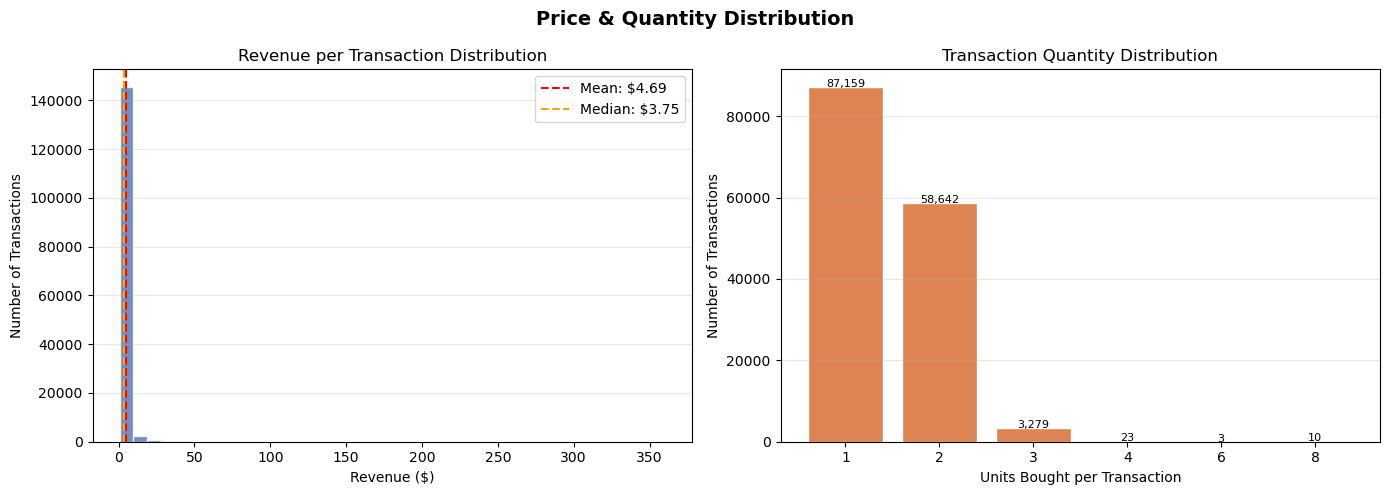

✅ Chart saved as price_qty_insights.png


In [261]:
# Step 6.4 — Chart: price distribution histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Price & Quantity Distribution", fontsize=14, fontweight="bold")

# Left — Revenue histogram
axes[0].hist(df["revenue"], bins=40, color="#4C72B0", edgecolor="white", alpha=0.8)
axes[0].axvline(df["revenue"].mean(), color="red", linestyle="--", label=f"Mean: ${df['revenue'].mean():.2f}")
axes[0].axvline(df["revenue"].median(), color="orange", linestyle="--", label=f"Median: ${df['revenue'].median():.2f}")
axes[0].set_title("Revenue per Transaction Distribution")
axes[0].set_xlabel("Revenue ($)")
axes[0].set_ylabel("Number of Transactions")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# Right — Quantity bar chart
axes[1].bar(qty_dist.index.astype(str), qty_dist.values, color="#DD8452", edgecolor="white")
axes[1].set_title("Transaction Quantity Distribution")
axes[1].set_xlabel("Units Bought per Transaction")
axes[1].set_ylabel("Number of Transactions")
for i, v in enumerate(qty_dist.values):
    axes[1].text(i, v + 50, f"{v:,}", ha="center", fontsize=8)
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("price_qty_insights.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved as price_qty_insights.png")

## Phase 7 — Final Summary Dashboard

In [262]:
# ============================================================
# PHASE 7 — SUMMARY DASHBOARD & KEY INSIGHTS
# Print a clean business-ready summary of everything
# ============================================================

print("\n")
print("╔══════════════════════════════════════════════════════════╗")
print("║       AFFICIONADO COFFEE ROASTERS — FULL SUMMARY        ║")
print("╚══════════════════════════════════════════════════════════╝")

total_revenue    = df["revenue"].sum()
total_txns       = len(df)
avg_order_value  = df["revenue"].mean()
best_store       = df.groupby("store_location")["revenue"].sum().idxmax()
best_category    = df.groupby("product_category")["revenue"].sum().idxmax()
best_product     = df.groupby("product_detail")["revenue"].sum().idxmax()
peak_hr          = df.groupby("hour")["revenue"].sum().idxmax()
peak_period      = df.groupby("time_period")["revenue"].sum().idxmax()

print(f"""
┌─────────────────────────────────────────────────────────┐
│  📊 KEY PERFORMANCE INDICATORS (KPIs)                   │
├─────────────────────────────────────────────────────────┤
│  Total Revenue          : ${total_revenue:>15,.2f}           │
│  Total Transactions     : {total_txns:>15,}           │
│  Avg Order Value        : ${avg_order_value:>15.2f}           │
├─────────────────────────────────────────────────────────┤
│  🏆 TOP PERFORMERS                                      │
├─────────────────────────────────────────────────────────┤
│  Best Store Location    : {best_store:<30} │
│  Best Product Category  : {best_category:<30} │
│  Best Individual Product: {best_product[:30]:<30} │
├─────────────────────────────────────────────────────────┤
│  ⏰ TIMING INSIGHTS                                     │
├─────────────────────────────────────────────────────────┤
│  Peak Hour              : {peak_hr:>2}:00                          │
│  Peak Time Period       : {peak_period:<30} │
└─────────────────────────────────────────────────────────┘
""")

print("📌 BUSINESS RECOMMENDATIONS:")
print(f"   1. Focus marketing on {best_store} — your highest revenue store")
print(f"   2. Stock up on {best_category} — it's your best-selling category")
print(f"   3. Schedule more staff at {peak_hr}:00 — that's your busiest hour")
print(f"   4. Promote '{best_product[:40]}' — top revenue product")
print(f"   5. Run promotions during Off-Peak hours to boost slow periods")
print("\n✅ Full analysis complete!")



╔══════════════════════════════════════════════════════════╗
║       AFFICIONADO COFFEE ROASTERS — FULL SUMMARY        ║
╚══════════════════════════════════════════════════════════╝

┌─────────────────────────────────────────────────────────┐
│  📊 KEY PERFORMANCE INDICATORS (KPIs)                   │
├─────────────────────────────────────────────────────────┤
│  Total Revenue          : $     698,812.33           │
│  Total Transactions     :         149,116           │
│  Avg Order Value        : $           4.69           │
├─────────────────────────────────────────────────────────┤
│  🏆 TOP PERFORMERS                                      │
├─────────────────────────────────────────────────────────┤
│  Best Store Location    : Hell's Kitchen                 │
│  Best Product Category  : Coffee                         │
│  Best Individual Product: Sustainably Grown Organic Lg   │
├─────────────────────────────────────────────────────────┤
│  ⏰ TIMING INSIGHTS                        

In [263]:
df.to_csv("afficionado_coffee_cleaned_df_final.csv", index=False)

In [264]:
import pandas as pd

test = pd.read_csv("afficionado_coffee_cleaned_df_final.csv")

print(test.columns.tolist())
print(test.head())

['transaction_id', 'year', 'transaction_time', 'transaction_qty', 'store_id', 'store_location', 'product_id', 'unit_price', 'product_category', 'product_type', 'product_detail', 'revenue', 'hour', 'minute', 'time_period']
   transaction_id  year     transaction_time  transaction_qty  store_id  \
0               1  2025  1900-01-01 07:06:11                2         5   
1               2  2025  1900-01-01 07:08:56                2         5   
2               3  2025  1900-01-01 07:14:04                2         5   
3               4  2025  1900-01-01 07:20:24                1         5   
4               5  2025  1900-01-01 07:22:41                2         5   

    store_location  product_id  unit_price    product_category  \
0  Lower Manhattan          32         3.0              Coffee   
1  Lower Manhattan          57         3.1                 Tea   
2  Lower Manhattan          59         4.5  Drinking Chocolate   
3  Lower Manhattan          22         2.0              Coffee 

In [265]:
import os
print(os.getcwd())

C:\Users\SANDEEP\Unified_mentor_projects
